# Koji build lag on the IBM architectures

s390x and ppc64le together, because both mean asking IBM for hardware and
because they are each other's control: they reach the same utilisation from
opposite directions and only one of them queues.

Almost every number below comes from `koji-lag report --json` and
`koji-lag events` rather than from SQL against the store. That is deliberate —
a metric computed in a notebook cell exists nowhere else, and a finding that
needs Jupyter to reproduce has excluded most of the people who might act on
it. One cell still queries the store directly and says why.

## Setup

In [1]:
import json, os, subprocess, shutil, tempfile, pathlib
import pandas as pd
import matplotlib.pyplot as plt

STORE = os.environ.get("KOJI_LAG_STORE") or os.path.expanduser(
    "~/src/github/slopfest/sandogasa/scratch/lag.sqlite")
# Prefer a release build from a checkout, else whatever `cargo install` put
# on PATH.
KOJI_LAG = os.environ.get("KOJI_LAG") or next(
    (p for p in [os.path.expanduser(
        "~/src/github/slopfest/sandogasa/target/release/koji-lag")]
     if os.path.exists(p)), shutil.which("koji-lag"))
if not KOJI_LAG or not os.path.exists(STORE):
    raise SystemExit(f"need koji-lag on PATH and a store; got {KOJI_LAG=} {STORE=}")

FOCUS = ["s390x", "ppc64le"]

def report(since, until, arches=FOCUS, extra=()):
    """One `koji-lag report --json`, as a dict."""
    cmd = [KOJI_LAG, "report", "--store", STORE, "--json",
           "--since", since, "--until", until, *extra]
    if arches:
        cmd += ["--arch", ",".join(arches)]
    out = subprocess.run(cmd, capture_output=True, text=True, check=True)
    return json.loads(out.stdout)

def health_frame(rep, key):
    """`health.arches`, `.classes` or `.cohorts` as a DataFrame."""
    rows = rep["health"][key]
    return pd.DataFrame(rows) if rows else pd.DataFrame()

def secs(d, field="median"):
    """Pull a field out of a DistSummary column of dicts, in minutes."""
    return d.apply(lambda w: None if not w else w[field] / 60.0)

print(f"koji-lag: {KOJI_LAG}\nstore:    {STORE}")

koji-lag: /home/michel/src/github/slopfest/sandogasa/target/release/koji-lag
store:    /home/michel/src/github/slopfest/sandogasa/scratch/lag.sqlite


## The windows worth looking at

`koji-lag events` detects mass rebuilds from who submitted each day, and
single-architecture stalls from queue wait against peers. Nothing here
re-implements that detection.

In [2]:
EVENTS = pathlib.Path(os.environ.get("KOJI_LAG_EVENTS") or tempfile.mkdtemp())
if not (EVENTS / "events").exists():
    cmd = [KOJI_LAG, "events", "--store", STORE, "--out", str(EVENTS)]
    # With a schedule checkout each event names the release it fell in, and a
    # rebuild reports its announced dates beside the observed ones.
    sched = os.environ.get("FEDORA_SCHEDULE") or os.path.expanduser(
        "~/src/fedora/forge/fedora-pgm-schedule")
    if os.path.isdir(sched):
        cmd += ["--schedule", sched]
    subprocess.run(cmd, check=True, capture_output=True)

events = []
for j in sorted((EVENTS / "events").glob("*/event.json")):
    e = json.loads(j.read_text())
    e["dir"] = j.parent.name
    events.append(e)
events = pd.DataFrame(events)
events["from_d"] = pd.to_datetime(events["from"], unit="s", utc=True).dt.date
events["to_d"] = pd.to_datetime(events["to"] - 86400, unit="s", utc=True).dt.date

rebuilds = events[events.kind == "mass-rebuild"].sort_values("from")
display(events.groupby("kind").size().rename("events"))
display(rebuilds[["from_d", "to_d", "days", "release"]])

kind
congestion      18
mass-rebuild     4
outage           2
Name: events, dtype: int64

,from_d,to_d,days,release
0,2025-01-16,2025-01-19,4,42
1,2025-07-23,2025-07-26,4,43
11,2026-01-16,2026-01-19,4,44
20,2026-07-15,2026-07-18,4,45


## Utilisation against the wait actually seen

The table that separates a capacity problem from a speed problem.

utilisation       rebuild_wait_h      
arch           ppc64le s390x        ppc64le s390x
window                                           
2025-01-16        0.41  0.54           0.01  0.02
2025-07-23        0.81  0.72           0.04  1.93
2026-01-16        0.88  0.78           0.07  4.22
2026-07-15        1.23  1.19           0.10  3.84

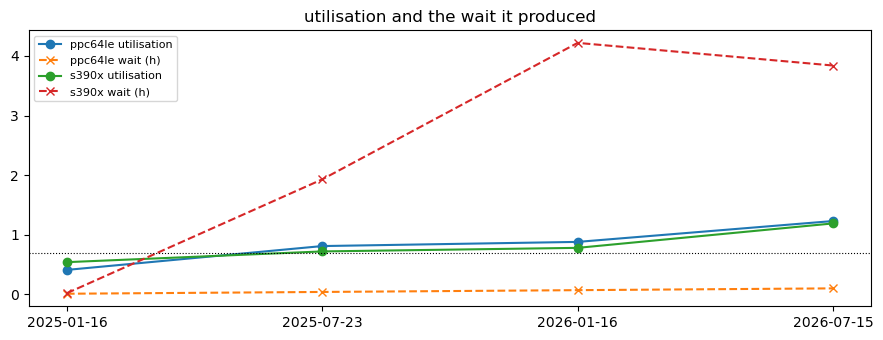

In [3]:
rows = []
for _, r in rebuilds.iterrows():
    rep = report(str(r.from_d), str(r.to_d))
    arches = health_frame(rep, "arches").set_index("arch")
    classes = health_frame(rep, "classes")
    for arch in FOCUS:
        if arch not in arches.index:
            continue
        reb = classes[(classes.arch == arch) & (classes["class"] == "mass-rebuild")]
        wait = reb.queue_wait.iloc[0] if len(reb) else None
        rows.append(dict(
            window=str(r.from_d), release=r.release, arch=arch,
            capacity=arches.loc[arch, "capacity"],
            offered=arches.loc[arch, "offered_weight"],
            utilisation=arches.loc[arch, "utilisation"],
            rebuild_wait_h=None if not wait else wait["median"] / 3600.0,
            rebuild_p90_h=None if not wait else wait["p90"] / 3600.0,
        ))
util = pd.DataFrame(rows).round(2)
display(util.pivot(index="window", columns="arch",
                   values=["utilisation", "rebuild_wait_h"]))

fig, ax = plt.subplots(figsize=(9, 3.5))
for arch, g in util.groupby("arch"):
    ax.plot(g.window, g.utilisation, marker="o", label=f"{arch} utilisation")
    ax.plot(g.window, g.rebuild_wait_h, marker="x", ls="--", label=f"{arch} wait (h)")
ax.axhline(0.7, color="k", lw=0.8, ls=":")
ax.legend(fontsize=8); ax.set_title("utilisation and the wait it produced")
plt.tight_layout(); plt.show()

## Queue wait by class of build

Never summed across classes: adding a rebuild's wait to a maintainer's is how
a headline once described releng waiting for releng.

In [4]:
last = rebuilds.iloc[-1]
rep = report(str(last.from_d), str(last.to_d))
cls = health_frame(rep, "classes")
cls["median_m"] = secs(cls.queue_wait)
cls["p90_m"] = secs(cls.queue_wait, "p90")
cls["tasks"] = cls.queue_wait.apply(lambda w: w and w["count"])
display(cls[["arch", "class", "tasks", "median_m", "p90_m", "over_hour_pct"]]
        .round(1).sort_values(["arch", "p90_m"], ascending=[True, False]))

,arch,class,tasks,median_m,p90_m,over_hour_pct
0,ppc64le,mass-rebuild,23904,6.1,54.4,8.8
5,ppc64le,service,94,2.3,13.0,7.4
1,ppc64le,eln-sync,158,2.8,10.2,1.9
3,ppc64le,koschei,5828,1.0,2.3,0.0
2,ppc64le,eln-fix,15,0.9,1.1,6.7
4,ppc64le,ci,479,0.9,1.1,0.0
6,ppc64le,hand-scratch,245,0.9,1.1,0.0
7,ppc64le,official,836,0.9,1.1,0.0
10,s390x,eln-fix,9,0.9,711.4,11.1
8,s390x,mass-rebuild,12645,230.6,497.9,95.0


## Queue wait by submitter volume

The split a population median hides. Bands, not names.

,arch,cohort,people,share_of_tasks,median_m,p90_m,over_hour_pct
0,ppc64le,top-10,10,53.2,0.9,1.1,0.0
1,ppc64le,next-40,40,34.3,0.9,1.1,0.0
2,ppc64le,rest,52,12.4,0.9,1.1,0.0
3,s390x,top-10,10,59.4,1.1,23.0,8.4
4,s390x,next-40,40,31.5,0.9,2.8,0.0
5,s390x,rest,33,9.0,1.0,3.0,4.3


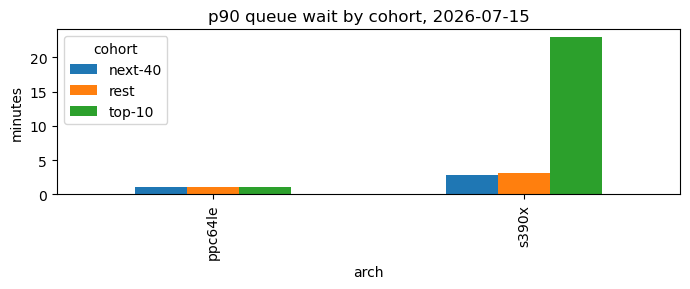

In [5]:
coh = health_frame(rep, "cohorts")
coh["median_m"] = secs(coh.queue_wait)
coh["p90_m"] = secs(coh.queue_wait, "p90")
display(coh[["arch", "cohort", "people", "share_of_tasks", "median_m", "p90_m",
             "over_hour_pct"]].round(1))

if not coh.empty:
    ax = coh.pivot(index="arch", columns="cohort", values="p90_m").plot.bar(
        figsize=(7, 3), title=f"p90 queue wait by cohort, {last.from_d}")
    ax.set_ylabel("minutes"); plt.tight_layout(); plt.show()

## Where builder time went, month by month

Utilisation, the share lost to failed or cancelled tasks, and the share held
by tasks over six hours.

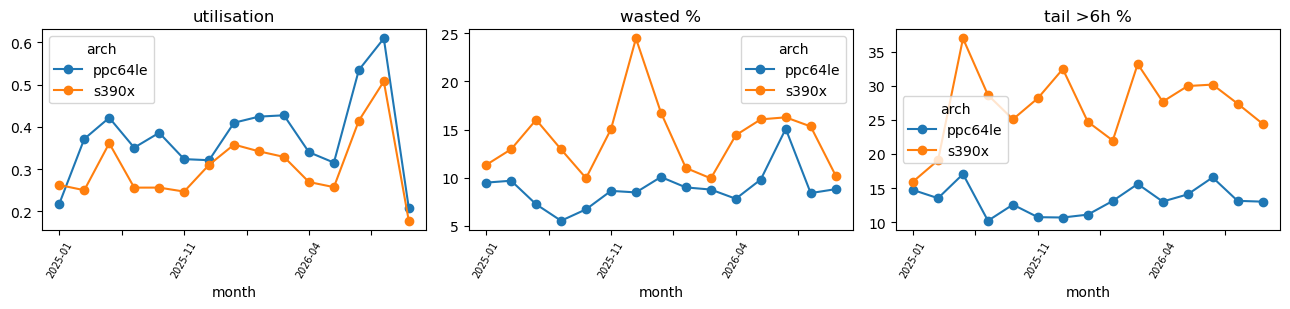

arch,ppc64le,s390x
month,,
2025-01,0.22,0.26
2025-07,0.37,0.25
2025-08,0.42,0.36
2025-09,0.35,0.26
2025-10,0.39,0.26
2025-11,0.32,0.25
2025-12,0.32,0.31
2026-01,0.41,0.36
2026-02,0.42,0.34


In [6]:
months = pd.date_range("2025-01-01", "2026-08-01", freq="MS", tz="UTC")
rows = []
for m in months:
    end = (m + pd.offsets.MonthEnd(1)).date()
    try:
        rep = report(str(m.date()), str(end))
    except subprocess.CalledProcessError:
        continue        # a month the store does not hold whole
    for a in rep["health"]["arches"]:
        if a["arch"] in FOCUS:
            rows.append(dict(month=str(m.date())[:7], **a))
trend = pd.DataFrame(rows)
if not trend.empty:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    for ax, col, title in zip(axes,
                              ["utilisation", "wasted_pct", "tail_pct"],
                              ["utilisation", "wasted %", "tail >6h %"]):
        trend.pivot(index="month", columns="arch", values=col).plot(ax=ax, marker="o")
        ax.set_title(title); ax.tick_params(axis="x", rotation=60, labelsize=7)
    plt.tight_layout(); plt.show()
    display(trend.pivot(index="month", columns="arch", values="utilisation").round(2))

## Service time, and the control that localises a regression

Every architecture, not just the two in focus: a change that moved all of
them is a toolchain or package-mix change, and one that moved a single
architecture is that architecture's problem.

arch,aarch64,i386,noarch,ppc64le,s390x,x86_64
window,,,,,,
2025-01-16,1.39,1.79,1.52,2.22,1.41,1.61
2025-07-23,1.50,1.48,1.20,2.25,2.02,1.29
2026-01-16,1.53,1.19,1.47,2.19,2.11,1.22
2026-07-15,1.52,1.24,1.50,2.04,2.31,1.26


arch
s390x      1.64
aarch64    1.09
noarch     0.99
ppc64le    0.92
x86_64     0.78
i386       0.69
Name: 2026-07-15 over 2025-01-16, dtype: float64

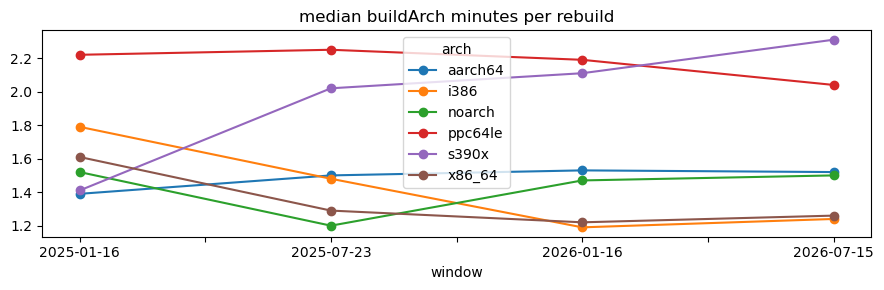

In [7]:
rows = []
for _, r in rebuilds.iterrows():
    rep = report(str(r.from_d), str(r.to_d), arches=None)
    for a in rep["arches"]:
        bt = a.get("build_time")
        if bt:
            rows.append(dict(window=str(r.from_d), arch=a["arch"],
                             median_m=bt["median"] / 60.0,
                             p90_m=bt["p90"] / 60.0))
svc = pd.DataFrame(rows)
wide = svc.pivot(index="window", columns="arch", values="median_m").round(2)
display(wide)
ratio = (wide.iloc[-1] / wide.iloc[0]).round(2).rename(
    f"{wide.index[-1]} over {wide.index[0]}")
display(ratio.sort_values(ascending=False))
wide.plot(figsize=(9, 3), marker="o", title="median buildArch minutes per rebuild")
plt.tight_layout(); plt.show()

## Single-architecture stalls

From `events` again — congestion when the builders were working harder than
usual, outage when they were doing less while the queue grew.

In [8]:
stalls = events[events.kind.isin(["congestion", "outage"])].copy()
stalls["cause"] = stalls.causes.apply(
    lambda cs: ", ".join(c["cause"] for c in cs) if cs else "")
display(stalls[["from_d", "to_d", "arch", "kind", "days", "cause"]]
        .sort_values("from_d").to_string(index=False))
print("\noutages without a recorded cause:",
      int(((stalls.kind == "outage") & (stalls.cause == "")).sum()))

'    from_d       to_d    arch       kind  days           cause\n2025-07-23 2025-07-26   s390x congestion     4                \n2025-08-13 2025-08-13   s390x congestion     1                \n2025-08-15 2025-08-16   s390x congestion     2                \n2025-08-20 2025-08-21   s390x congestion     2                \n2025-08-26 2025-08-26   s390x congestion     1                \n2025-09-19 2025-09-19 ppc64le congestion     1                \n2025-11-11 2025-11-11 ppc64le     outage     1 datacentre-move\n2025-11-27 2025-11-27   s390x congestion     1                \n2026-01-06 2026-01-07   s390x congestion     2                \n2026-01-16 2026-01-18   s390x congestion     3                \n2026-01-20 2026-01-20   s390x congestion     1                \n2026-03-26 2026-03-26   s390x congestion     1                \n2026-05-06 2026-05-08   s390x     outage     3         storage\n2026-05-12 2026-05-12   s390x congestion     1                \n2026-06-13 2026-06-13   s390x congestio


outages without a recorded cause: 0


## The one exception: slowdown by build toolchain

This queries the store directly, and needs a checkout of Fedora's spec files.
It stays here rather than moving into `report` because it joins per-package
durations against data from outside the store — the `BuildRequires` of each
spec — which the tool has no business fetching. Skipped when the specs are
absent.

In [9]:
import glob, re, sqlite3, statistics, collections, datetime
SPECS = os.environ.get("FEDORA_SPECS") or os.path.expanduser("~/src/fedora/rpm-specs")

def toolchains(path):
    out = {}
    for f in glob.glob(f"{path}/*.spec"):
        txt = open(f, errors="replace").read()
        br = " ".join(re.findall(r"^BuildRequires:\s*(.+)$", txt, re.M)).lower()
        if re.search(r"rust-packaging|%cargo_build|\bcargo\b", txt):
            c = "rust"
        elif re.search(r"gcc-c\+\+|clang\+\+|libstdc\+\+-devel", br):
            c = "c++"       # no trailing \b: it cannot match after ++
        elif re.search(r"\bgcc\b|\bclang\b", br):
            c = "c"
        else:
            c = "other"
        out[os.path.basename(f)[:-5]] = c
    return out

if not os.path.isdir(SPECS) or len(rebuilds) < 2:
    print(f"needs two rebuilds and specs at {SPECS}; skipping")
else:
    CLS = toolchains(SPECS)
    db = sqlite3.connect(f"file:{STORE}?mode=ro", uri=True)
    def durations(arch, a, b):
        ts = lambda d: datetime.datetime.strptime(str(d), "%Y-%m-%d").replace(
            tzinfo=datetime.UTC).timestamp()
        rows = db.execute("""
          SELECT coalesce(b.package, t.package), t.completion_ts - t.start_ts
          FROM tasks t JOIN builds b
            ON b.instance = t.instance AND b.task_id = t.parent
          WHERE t.instance = 'fedora' AND t.arch = ? AND t.method = 'buildArch'
            AND t.state = 2 AND t.completion_ts IS NOT NULL
            AND (b.target LIKE '%-rebuild' OR b.owner = 'releng')
            AND t.create_ts >= ? AND t.create_ts < ?""",
          (arch, ts(a), ts(b) + 86400)).fetchall()
        return {p: d for p, d in rows if p}

    first, last_w = rebuilds.iloc[0], rebuilds.iloc[-1]
    out = []
    for arch in ["s390x", "ppc64le", "aarch64", "x86_64"]:
        a = durations(arch, first.from_d, first.to_d)
        z = durations(arch, last_w.from_d, last_w.to_d)
        buck = collections.defaultdict(list)
        for pkg in set(a) & set(z):
            if a[pkg] > 30:          # sub-30s builds are buildroot overhead
                buck[CLS.get(pkg, "other")].append(z[pkg] / a[pkg])
        row = {"arch": arch}
        for k, v in buck.items():
            if len(v) >= 25:
                row[k] = statistics.median(v)
        out.append(row)
    paired = pd.DataFrame(out).set_index("arch").round(2)
    display(paired)
    if {"c++", "rust"} <= set(paired.columns):
        # rust does not consume Fedora's C flags, so c++/rust isolates the
        # compile-specific cost from whatever the platform did.
        display((paired["c++"] / paired["rust"]).round(2).rename("c++ / rust"))

,c++,other,rust,c
arch,,,,
s390x,1.53,1.30,1.16,1.40
ppc64le,0.96,0.89,0.73,0.93
aarch64,1.13,1.08,0.94,1.12
x86_64,0.79,0.78,0.69,0.81


arch
s390x      1.32
ppc64le    1.32
aarch64    1.20
x86_64     1.14
Name: c++ / rust, dtype: float64